In [37]:
import joblib
import pandas as pd
import numpy as np
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

ada_model = joblib.load("../models/adaboost_v6.pkl")
ada_model = ada_model["model"]
xgb_model = joblib.load("../models/xgboost_v21.pkl")
xgb_model = xgb_model["model"]

In [38]:
train_idx = np.load("../data/splits/train_idx.npy")
test_idx  = np.load("../data/splits/test_idx.npy")

X_train, y_train = X.iloc[train_idx], y[train_idx]
X_test,  y_test  = X.iloc[test_idx], y[test_idx]

In [39]:
X_test = X_test.reindex(columns=ada_model.feature_names_in_, fill_value=0)
X_test_xgb = X_test.reindex(columns=xgb_model.feature_names_in_, fill_value=0)

In [40]:
from sklearn.metrics import roc_curve, auc

ada_probs = ada_model.predict_proba(X_test)[:, 1]
ada_fpr, ada_tpr, _ = roc_curve(y_test, ada_probs)
ada_auc = auc(ada_fpr, ada_tpr)

xgb_probs = xgb_model.predict_proba(X_test_xgb)[:, 1]
xgb_fpr, xgb_tpr, _ = roc_curve(y_test, xgb_probs)
xgb_auc = auc(xgb_fpr, xgb_tpr)

In [41]:
ada_pred = ada_model.predict(X_test)
xgb_pred = xgb_model.predict(X_test_xgb)

ada_cm = confusion_matrix(y_test, ada_pred)
xgb_cm = confusion_matrix(y_test, xgb_pred)

In [42]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def get_scores(y_true, y_pred):
    return [
        accuracy_score(y_true, y_pred),
        precision_score(y_true, y_pred),
        recall_score(y_true, y_pred),
        f1_score(y_true, y_pred)
    ]

ada_scores = get_scores(y_test, ada_pred)
xgb_scores = get_scores(y_test, xgb_pred)

metrics_names = ["Accuracy", "Precision", "Recall", "F1"]

In [43]:
from sklearn.model_selection import learning_curve

train_sizes, train_scores, val_scores = learning_curve(
    ada_model, X_train, y_train,
    cv=5, scoring='roc_auc',
    train_sizes=np.linspace(0.1, 1.0, 5)
)

ada_train_aucs = train_scores.mean(axis=1)
ada_val_aucs   = val_scores.mean(axis=1)

In [30]:
from sklearn.metrics import roc_curve, auc, accuracy_score, precision_score, recall_score, f1_score

# Load splits
train_idx = np.load("../data/splits/train_idx.npy")
test_idx  = np.load("../data/splits/test_idx.npy")

X_train, y_train = X.iloc[train_idx], y[train_idx]
X_test,  y_test  = X.iloc[test_idx], y[test_idx]

# Align columns (IMPORTANT)
X_test_ada = X_test.reindex(columns=ada_model.feature_names_in_, fill_value=0)
X_test_xgb = X_test.reindex(columns=xgb_model.feature_names_in_, fill_value=0)

# ROC
ada_probs = ada_model.predict_proba(X_test_ada)[:, 1]
ada_fpr, ada_tpr, _ = roc_curve(y_test, ada_probs)
ada_auc = auc(ada_fpr, ada_tpr)

xgb_probs = xgb_model.predict_proba(X_test_xgb)[:, 1]
xgb_fpr, xgb_tpr, _ = roc_curve(y_test, xgb_probs)
xgb_auc = auc(xgb_fpr, xgb_tpr)

# Predictions
ada_pred = ada_model.predict(X_test_ada)
xgb_pred = xgb_model.predict(X_test_xgb)

# Metrics
def get_scores(y_true, y_pred):
    return [
        accuracy_score(y_true, y_pred),
        precision_score(y_true, y_pred),
        recall_score(y_true, y_pred),
        f1_score(y_true, y_pred)
    ]

ada_scores = get_scores(y_test, ada_pred)
xgb_scores = get_scores(y_test, xgb_pred)

metrics_names = ["Accuracy", "Precision", "Recall", "F1"]

In [32]:
def style_ax(ax, title):
    BG_WHITE = '#FFFFFF'
    TEXT     = '#212529'
    MUTED    = '#495057'
    GRID     = '#DEE2E6'
    
    ax.set_facecolor(BG_WHITE)
    ax.tick_params(colors=MUTED, labelsize=9)
    ax.set_title(title, fontsize=12, fontweight='bold', color=TEXT, pad=12)
    
    for spine in ax.spines.values():
        spine.set_edgecolor(GRID)
    
    ax.grid(True, linestyle='-', color=GRID, linewidth=0.5, alpha=0.7)

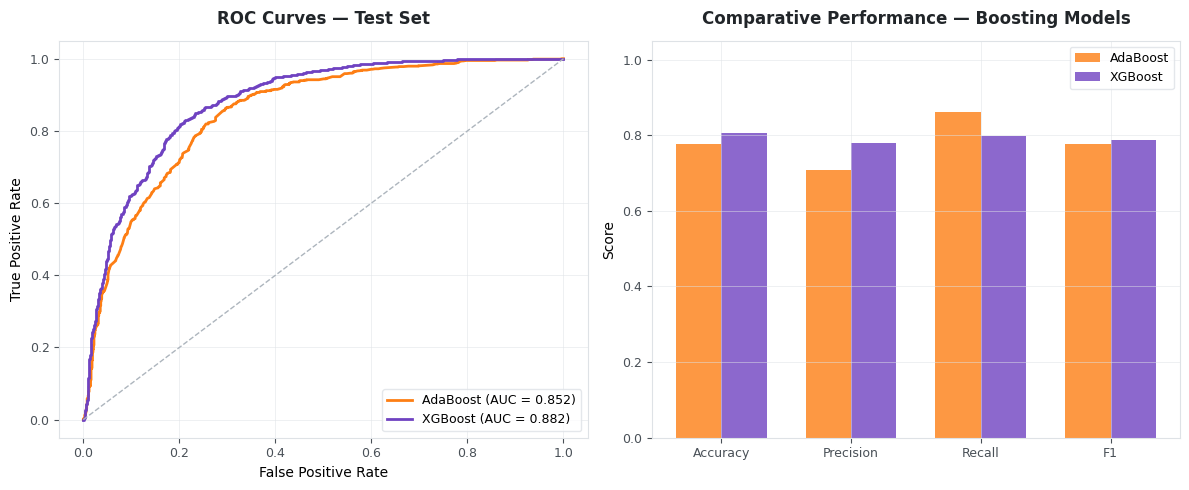

In [33]:
fig_small, (ax1, ax4) = plt.subplots(1, 2, figsize=(12, 5))
fig_small.patch.set_facecolor('#FFFFFF')

# Colors (match your theme)
ADA_COL = '#FD7E14'
XGB_COL = '#6F42C1'
AX_GRAY = '#FFFFFF'
GRID = '#DEE2E6'

# Panel 1: ROC Curves
ax1.plot(ada_fpr, ada_tpr, color=ADA_COL, lw=2,
         label=f'AdaBoost (AUC = {ada_auc:.3f})')
ax1.plot(xgb_fpr, xgb_tpr, color=XGB_COL, lw=2,
         label=f'XGBoost (AUC = {xgb_auc:.3f})')
ax1.plot([0,1],[0,1], color='#ADB5BD', lw=1, linestyle='--')
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.legend(fontsize=9, facecolor=AX_GRAY, edgecolor=GRID)
style_ax(ax1, 'ROC Curves — Test Set')

# Panel 2: Metrics Comparison
x = np.arange(len(metrics_names))
w = 0.35

ax4.bar(x - w/2, ada_scores, w, color=ADA_COL, alpha=0.8, label='AdaBoost')
ax4.bar(x + w/2, xgb_scores, w, color=XGB_COL, alpha=0.8, label='XGBoost')

ax4.set_xticks(x)
ax4.set_xticklabels(metrics_names, fontsize=9)
ax4.set_ylim(0, 1.05)
ax4.set_ylabel('Score')
ax4.legend(fontsize=9, facecolor=AX_GRAY, edgecolor=GRID)
style_ax(ax4, 'Comparative Performance — Boosting Models')

plt.tight_layout()
plt.savefig('../figures/ada_vs_xgb.png', dpi=300, bbox_inches='tight')
plt.show()

In [36]:
ada_model.get_params()

{'algorithm': 'deprecated',
 'estimator__ccp_alpha': 0.0,
 'estimator__class_weight': None,
 'estimator__criterion': 'gini',
 'estimator__max_depth': 1,
 'estimator__max_features': None,
 'estimator__max_leaf_nodes': None,
 'estimator__min_impurity_decrease': 0.0,
 'estimator__min_samples_leaf': 1,
 'estimator__min_samples_split': 2,
 'estimator__min_weight_fraction_leaf': 0.0,
 'estimator__monotonic_cst': None,
 'estimator__random_state': None,
 'estimator__splitter': 'best',
 'estimator': DecisionTreeClassifier(max_depth=1),
 'learning_rate': 0.5,
 'n_estimators': 400,
 'random_state': 42}